In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/train-test-deepnn/X_test_processed.csv
/kaggle/input/train-test-deepnn/y_test_processed.csv
/kaggle/input/train-test-deepnn/y_train_processed.csv
/kaggle/input/train-test-deepnn/X_train_processed.csv


In [4]:
# Importing necessary libraries
import pandas as pd
import numpy as np 
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc

### Splitting data into training and testing sets

In [5]:
# Importing processed split dataset from previous notebook "Feature Engineering"
with open ("/kaggle/input/diabetes-dataset-updated/train_dev_test_data.pkl", "rb") as f:
    X_train, X_dev, X_test, y_train, y_dev, y_test = pickle.load(f)

In [6]:
# Convert dataframes to a matrices for Logistic regression implementation
def to_numpy_format(df): 
    data = df.to_numpy()
    data = data.T 
    return data

X_train, X_dev, X_test, y_train, y_dev, y_test = [to_numpy_format(df) for df in [X_train, X_dev, X_test, y_train,y_dev, y_test]]

def initialize_parameters (layer_dims):
    np.random.seed(1)
    parameters = {}
    # Will use Hue Initialization for layers with ReLu Activation Function (We overlooked sigmoid function for the output layer)
    for i in range(1,len(layer_dims)): 
        parameters["W" + str(i)] = (np.random.randn(layer_dims[i], layer_dims[i-1])) * np.sqrt(2./ layer_dims[i-1])
        parameters["b" + str(i)] = np.zeros((layer_dims[i], 1))
    return parameters
# Function for calculating velocities to perform gradient descent with momentum 
def initialize_velocities (parameters):
    L = len(parameters) // 2 
    v = {}
    for l in range (1, L+1):
        v["dW" + str(l)] = np.zeros_like(parameters["W" + str(l)])
        v["db" + str(l)] = np.zeros_like(parameters["b" + str(l)])
    return v 
def initialize_rms (parameters): 
    L = len(parameters) // 2 
    s = {}
    for l in range (1, L+1) : 
        s['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        s['db' + str(l)] = np.zeros_like(parameters["b" + str(l)])
    return s 
def initialize_adam (parameters) : 
    v = initialize_velocities(parameters)
    s = initialize_rms (parameters)

    return v, s

def linear_forward (X, W, b): 
    Z = np.dot(W,X) + b  # Shape (n_l,m)
    cache = (X,W,b)
    return Z, cache

def linear_activation_forward (A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == 'relu': 
        A = np.maximum(0,Z)
    else:
        A = 1/ (1+np.exp(-Z))
    activation_cache = Z
    cache = (linear_cache, activation_cache)
    return A, cache 

def L_model_forward (X,parameters): 
    L = len(parameters) // 2 
    A_prev = X 
    caches = []
    for l in range (L-1): 
        A, cache = linear_activation_forward(A_prev, parameters["W" + str(l+1)], parameters["b"+str(l+1)], activation='relu')
        A_prev = A
        caches.append(cache)
    AL, cache = linear_activation_forward(A_prev, parameters["W" + str(L)], parameters["b"+str(L)], activation='sigmoid')
    caches.append(cache)
    return AL, caches 

def compute_cost (AL, Y): 
    m = Y.shape[1]
    epsilon = 1e-8  # small constant
    AL_clipped = np.clip(AL, epsilon, 1 - epsilon)
    cost = (-1/m) * np.sum((Y* np.log(AL_clipped)) + ((1-Y) * np.log(1-AL_clipped)))
    return cost

def derivative_relu(Z):
    dZ = np.array(Z > 0, dtype=float)
    return dZ

def backward_prop (AL, caches, Y): 
    m = Y.shape[1]
    L = len(caches)
    grads = {}
    current_cache = caches[L-1]
    linear_cache, activation_cache = current_cache
    A_prev, W, b = linear_cache
    dZ = AL - Y
    grads["dW" + str(L)] = (1/m) * np.dot(dZ, A_prev.T)
    grads["db" + str(L)] = (1/m) * np.sum(dZ, axis = 1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        linear_cache, activation_cache = current_cache
        A_prev, W, b = linear_cache
        Z_prev = activation_cache
        dZ_prev = dA_prev * derivative_relu(Z_prev)
        grads["dW" + str(l+1)] = (1/m) * np.dot(dZ_prev, A_prev.T)
        grads["db" + str(l+1)] = (1/m) * np.sum (dZ_prev, axis = 1, keepdims=True)        
        dA_prev = np.dot(W.T, dZ_prev)
    return grads
    
def gradient_descent_momentum(parameters, grads, v, learning_rate, beta1):
    L = len(parameters) // 2

    for l in range(1, L+1):
        # Update velocities
        v["dW" + str(l)] = beta1 * v["dW" + str(l)] + (1 - beta1) * grads["dW" + str(l)]
        v["db" + str(l)] = beta1 * v["db" + str(l)] + (1 - beta1) * grads["db" + str(l)]

        # Update parameters
        parameters["W" + str(l)] -= learning_rate * v["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * v["db" + str(l)]

    return parameters, v
def gradient_descent_rms (parameters, grads, s, learning_rate, beta2, epsilon) :
    L = len (parameters) // 2 

    for l in range(1, L+1) : 
        s['dW' + str(l)] = (beta2 * s['dW' + str(l)]) + (1 - beta2) * (grads['dW' + str(l)] ** 2)
        s['db' + str(l)] = (beta2 * s['db' + str(l)]) + (1 - beta2) * (grads['db' + str(l)] ** 2)

        parameters["W" + str(l)] -= learning_rate * (grads["dW" + str(l)] / (np.sqrt(s['dW' + str(l)]) + epsilon))
        parameters["b" + str(l)] -= learning_rate * (grads["db" + str(l)] / (np.sqrt(s['db' + str(l)]) + epsilon))  
    return parameters, s
    
def gradient_descent_adam (parameters, grads, v, s, learning_rate, beta1, beta2, epsilon, t) : 
    L = len(parameters) // 2 
    v_corrected = {}
    s_corrected = {}
    for l in range (1, L+1): 
        # Momentum and Momentum Corrected 
        v["dW" + str(l)] = beta1 * v["dW" + str(l)] + (1 - beta1) * grads["dW" + str(l)] 
        v["db" + str(l)] = beta1 * v["db" + str(l)] + (1 - beta1) * grads["db" + str(l)]
        v_corrected["dW" + str(l)] = v["dW" + str(l)]/ (1 - (beta1 ** t))
        v_corrected["db" + str(l)] = v["db" + str(l)]/ (1 - (beta1 ** t))
        
        # RMS Prop and RMS Prop Corrected 
        s['dW' + str(l)] = (beta2 * s['dW' + str(l)]) + (1 - beta2) * (grads['dW' + str(l)] ** 2)
        s['db' + str(l)] = (beta2 * s['db' + str(l)]) + (1 - beta2) * (grads['db' + str(l)] ** 2)
        s_corrected["dW" + str(l)] = s["dW" + str(l)]/ (1 - (beta2 ** t))
        s_corrected["db" + str(l)] = s["db" + str(l)]/ (1 - (beta2 ** t))

        # Parameters Update 
        parameters["W" + str(l)] -= learning_rate * (v_corrected["dW" + str(l)] / (np.sqrt(s_corrected["dW" + str(l)]) + epsilon))
        parameters["b" + str(l)] -= learning_rate * (v_corrected["db" + str(l)] / (np.sqrt(s_corrected['db' + str(l)]) + epsilon))

    return parameters, v, s 

def model(X, layer_dims, Y, num_iterations, learning_rate, beta1, beta2, epsilon , print_cost = False) : 
    parameters = initialize_parameters(layer_dims)
    v, s = initialize_adam (parameters)
    costs = []
    for i in range (1, num_iterations + 1) : 
        AL, caches = L_model_forward (X, parameters)
        cost = compute_cost(AL, Y)
        costs.append(cost)
        grads = backward_prop (AL, caches, Y) 
        parameters, v, s = gradient_descent_adam (parameters, grads, v, s, learning_rate, beta1, beta2, epsilon, i)

        if print_cost and (i % 100) == 0 : 
            print (f"Cost at iteration {i} : {cost}")
    return parameters, costs 


layer_dims = [X_train.shape[0], 6, 6, 5, 1]
parameters, costs =  model (X_train, layer_dims, y_train, num_iterations = 10000, learning_rate = 0.01, beta1 = 0.9, beta2 = 0.999, epsilon =  1e-8, print_cost=True)




Cost at iteration 100 : 0.12279485373297203
Cost at iteration 200 : 0.1115148971544586
Cost at iteration 300 : 0.11084814784782504
Cost at iteration 400 : 0.10914750614343001
Cost at iteration 500 : 0.10756456768397943
Cost at iteration 600 : 0.1065864365561452
Cost at iteration 700 : 0.10580523947444108
Cost at iteration 800 : 0.10528397218289677
Cost at iteration 900 : 0.10511340766502454
Cost at iteration 1000 : 0.10489255751485008
Cost at iteration 1100 : 0.10467161961263377
Cost at iteration 1200 : 0.10440998448725007
Cost at iteration 1300 : 0.10432160638815678
Cost at iteration 1400 : 0.10413750777200732
Cost at iteration 1500 : 0.09800694370565907
Cost at iteration 1600 : 0.09709181058452757
Cost at iteration 1700 : 0.09421815702618393
Cost at iteration 1800 : 0.09555369443827766
Cost at iteration 1900 : 0.09391071746051094
Cost at iteration 2000 : 0.09384967827090686
Cost at iteration 2100 : 0.09550089814755242
Cost at iteration 2200 : 0.09404453027273425
Cost at iteration 230

In [21]:
def predict (X, parameters) : 
    Y_pred,_ = L_model_forward (X,parameters) 
    Y_pred = (Y_pred >= 0.4).astype(int)
    return Y_pred

def accuracy (Y_pred, y_test) : 
    acc = 100 * np.mean (Y_pred == y_test)
    return acc 
Y_train_pred = predict (X_train, parameters)
train_acc = accuracy (Y_train_pred, y_train)
print (f"Training Accuracy of a {len(layer_dims) - 2} hidden layers model is: {train_acc:2f}%")
Y_test_pred = predict (X_test, parameters)
test_acc = accuracy (Y_test_pred, y_test)
print (f"Testing Accuracy of a {len(layer_dims) - 2} hidden layers model is: {test_acc:2f}%")

Training Accuracy of a 3 hidden layers model is: 97.143214%
Testing Accuracy of a 3 hidden layers model is: 97.049557%


In [22]:
# Model Evaluation
# Compare to Baseline, to see if a model only dumbly predicts one class how well does it perform? 
baseline_acc = 100 * max(np.mean(y_test), 1 - np.mean(y_test))
print(f"Baseline (majority class) accuracy: {baseline_acc:.2f}%")

Baseline (majority class) accuracy: 91.12%


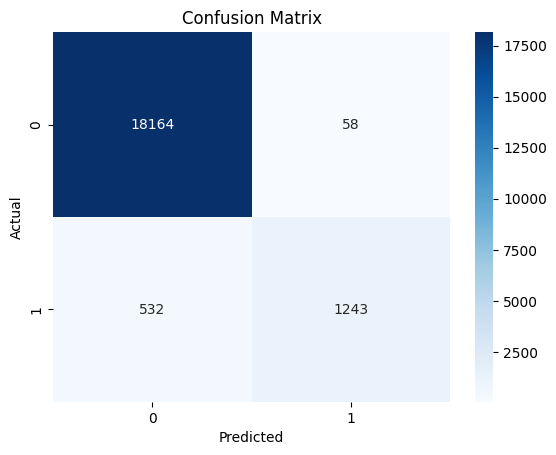

In [23]:
cm = confusion_matrix(y_test.flatten(), Y_test_pred.flatten())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
print(classification_report(y_test.flatten(), Y_test_pred.flatten(), target_names=['Non-Diabetic','Diabetic']))

              precision    recall  f1-score   support

Non-Diabetic       0.97      1.00      0.98     18222
    Diabetic       0.96      0.70      0.81      1775

    accuracy                           0.97     19997
   macro avg       0.96      0.85      0.90     19997
weighted avg       0.97      0.97      0.97     19997



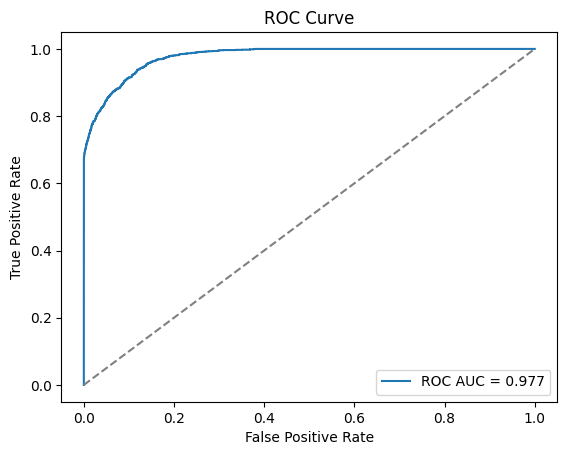

In [26]:
AL_test, _ = L_model_forward(X_test, parameters)
y_proba = AL_test.flatten()

fpr, tpr, _ = roc_curve(y_test.flatten(), y_proba)
roc_auc = roc_auc_score(y_test.flatten(), y_proba)

plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

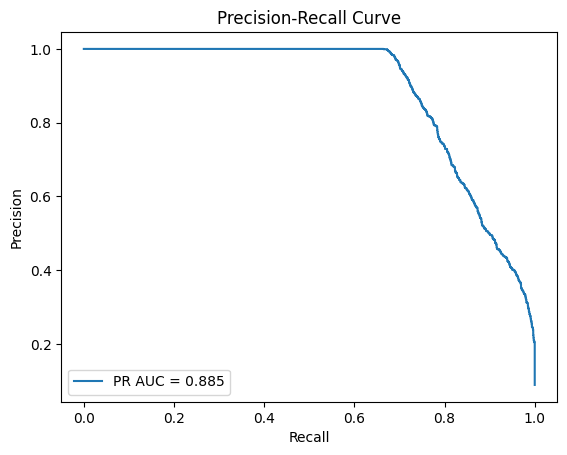

In [28]:
prec, rec, _ = precision_recall_curve(y_test.flatten(), y_proba)
pr_auc = auc(rec, prec)
plt.plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()